Accuracy: 0.9155405405405406
[[124  10]
 [ 15 147]]
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       134
           1       0.94      0.91      0.92       162

    accuracy                           0.92       296
   macro avg       0.91      0.92      0.92       296
weighted avg       0.92      0.92      0.92       296



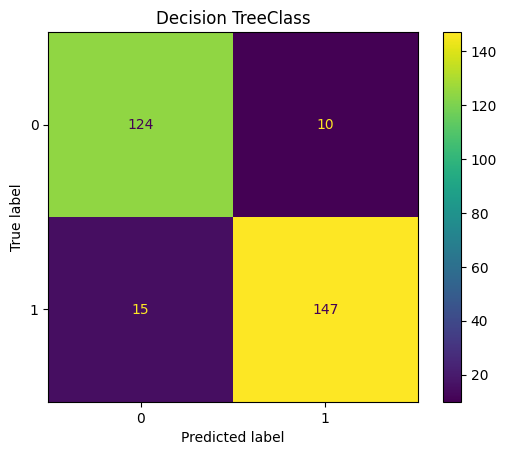

In [1]:
# 1. Imports
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# 2. Load dataset
df = pd.read_csv("creditcard.csv")

# 3. Preprocessing
fraud = df[df.Class == 1]
normal = df[df.Class == 0]

normal_sample = resample(normal, replace=False,
                         n_samples=len(fraud), random_state=42)

df_balanced = pd.concat([fraud, normal_sample])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

X = df_balanced.drop('Class', axis=1)
y = df_balanced['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# 5. Evaluation
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# 6. Plot
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Decision TreeClass")
plt.show()